In [1]:
# ============================================================
# CELL 1 – Setup & Imports
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize
from collections import Counter
import itertools
import seaborn as sns

from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

# ---------------- CONFIG ----------------
SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
LABELED_FRACTION = 0.20   # only 20% labeled used for supervised training
USE_CLASS_WEIGHTS = True
UNFREEZE_LAST_N = 40
EPOCHS_SSL_PRE = 30        # SimCLR pretraining epochs
EPOCHS_SUP = 10           # Supervised fine-tuning epochs

2025-12-01 10:00:36.352369: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764583236.546875      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764583236.603487      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================================
# CELL 1.1 – Load HAM10000 Metadata & Map Filepaths
# ============================================================
ROOT = "/kaggle/input/skin-cancer-mnist-ham10000"
CSV_PATH = os.path.join(ROOT, "HAM10000_metadata.csv")

meta = pd.read_csv(CSV_PATH)
print("Metadata head:\n", meta.head())

# Possible image folders
IMG_DIRS = [os.path.join(ROOT, d) for d in [
    "ham10000_images_part_1",
    "ham10000_images_part_2",
    "HAM10000_images",
    "ham10000_images"
] if os.path.exists(os.path.join(ROOT, d))]

def resolve_path(img_id):
    for d in IMG_DIRS:
        p = os.path.join(d, f"{img_id}.jpg")
        if os.path.exists(p):
            return p
    return None

meta["filepath"] = meta["image_id"].apply(resolve_path)
missing = meta["filepath"].isna().sum()
assert missing == 0, f"{missing} images not found; check paths."

# Label mapping (dx → integer)
classes = sorted(meta["dx"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
meta["label"] = meta["dx"].map(class_to_idx)

# Remove duplicates just in case
meta = meta.drop_duplicates(subset=["filepath"]).reset_index(drop=True)

print("Class distribution (original):\n", meta["dx"].value_counts())
print("Total samples:", len(meta))
print("Class_to_idx:", class_to_idx)

NUM_CLASSES = len(classes)

Metadata head:
      lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Class distribution (original):
 dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Total samples: 10015
Class_to_idx: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


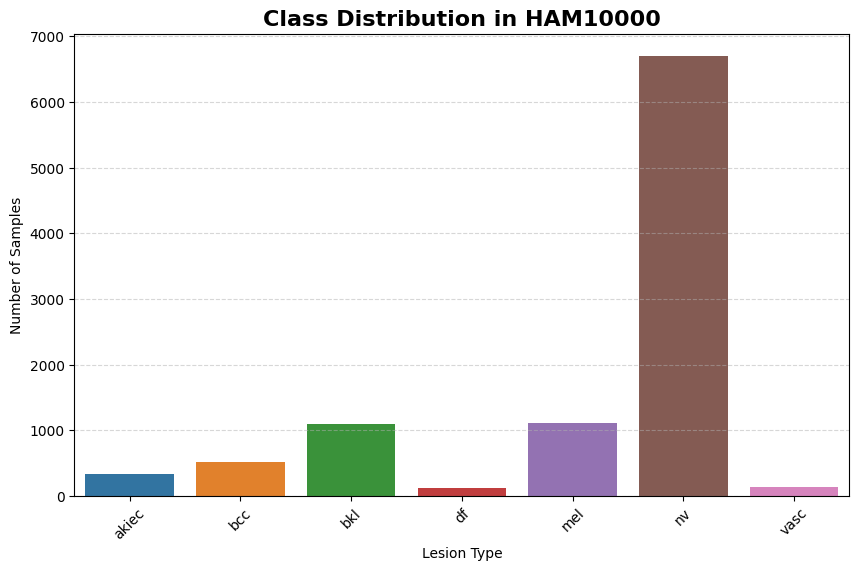


Total Images = 10015


In [3]:
# ============================================================
# CELL 1.2 – Visualize Class Distribution
# ============================================================
class_counts = meta["label"].value_counts().sort_index()
class_names = [idx_to_class[i] for i in class_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=class_names, y=class_counts.values)
plt.title("Class Distribution in HAM10000", fontsize=16, fontweight="bold")
plt.xlabel("Lesion Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

print(f"\nTotal Images = {meta.shape[0]}")

In [4]:
# ============================================================
# CELL 2 – Train/Val/Test Split + Limited Labeled Subset
# ============================================================
# Stratified Train / Test
train_df, test_df = train_test_split(
    meta,
    test_size=0.20,
    stratify=meta["label"],
    random_state=SEED
)

# Split a validation set from train
train_df, val_df = train_test_split(
    train_df,
    test_size=0.10,
    stratify=train_df["label"],
    random_state=SEED
)

print("Train / Val / Test sizes:", len(train_df), len(val_df), len(test_df))

# Stratified sampling to simulate limited labels (10% labeled)
def stratified_sample(df, frac, label_col="label"):
    chunks = []
    for y, g in df.groupby(label_col):
        n = max(1, int(len(g) * frac))
        chunks.append(g.sample(n=n, random_state=SEED))
    return pd.concat(chunks).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_limited_df = stratified_sample(train_df, LABELED_FRACTION, "label")
print("Limited-labeled TRAIN size:", len(train_limited_df))
print("Class distribution (limited):", Counter(train_limited_df["label"]))

# Class weights to handle imbalance on limited set
if USE_CLASS_WEIGHTS:
    y_train = train_limited_df["label"].values
    class_weights_arr = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUM_CLASSES),
        y=y_train
    )
    CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(class_weights_arr)}
else:
    CLASS_WEIGHTS = None

print("CLASS_WEIGHTS:", CLASS_WEIGHTS)

Train / Val / Test sizes: 7210 802 2003
Limited-labeled TRAIN size: 1440
Class distribution (limited): Counter({5: 965, 4: 160, 2: 158, 1: 74, 0: 47, 6: 20, 3: 16})
CLASS_WEIGHTS: {0: 4.376899696048632, 1: 2.77992277992278, 2: 1.301989150090416, 3: 12.857142857142858, 4: 1.2857142857142858, 5: 0.21317542561065878, 6: 10.285714285714286}


In [5]:
# ============================================================
# CELL 3 – tf.data Pipelines with Augmentation
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE

augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.05),
    layers.RandomBrightness(0.1),
    layers.RandomZoom(0.1),
])

def decode_img(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method="bilinear")
    return img

def make_ds(df, training=True):
    paths = df["filepath"].values
    labels = df["label"].values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, y):
        x = decode_img(path)
        x = tf.cast(x, tf.float32)
        if training:
            x = augment(x)
        x = preprocess_input(x)  # ResNet50-style normalization
        return x, y

    if training:
        ds = ds.shuffle(2048, seed=SEED)

    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_limited_df, training=True)  # labeled 10%
val_ds   = make_ds(val_df, training=False)
test_ds  = make_ds(test_df, training=False)

I0000 00:00:1764583277.620138      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1764583277.620735      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
# ============================================================
# CELL 4 – Supervised Models: ResNet50 & EfficientNetB0
# ============================================================
from tensorflow.keras.applications import ResNet50, EfficientNetB0

def build_resnet50_classifier(train_backbone=False, unfreeze_from=None):
    base = ResNet50(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = train_backbone
    if train_backbone and (unfreeze_from is not None):
        for layer in base.layers[:-unfreeze_from]:
            layer.trainable = False

    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = models.Model(inp, out, name="resnet50_supervised")
    return model

# def build_efficientnetb0_classifier():
#     base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
#     base.trainable = False  # only head will be trained (lightweight)
#     inp = layers.Input(shape=(*IMG_SIZE, 3))
#     x = base(inp, training=False)
#     x = layers.GlobalAveragePooling2D()(x)
#     x = layers.Dropout(0.25)(x)
#     out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
#     model = models.Model(inp, out, name="efficientnetb0_supervised")
#     return model

def build_efficientnetb0(train_backbone=True, unfreeze_from=50):
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    
    # Unfreeze some layers
    base.trainable = train_backbone
    if train_backbone and unfreeze_from is not None:
        for layer in base.layers[:-unfreeze_from]:
            layer.trainable = False
    
    inp = layers.Input(shape=(*IMG_SIZE, 3))
    x = base(inp, training=True)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inp, out)


resnet50_model = build_resnet50_classifier(train_backbone=True, unfreeze_from=UNFREEZE_LAST_N)
# effnetb0_model = build_efficientnetb0_classifier()
effnetb0_model = build_efficientnetb0(train_backbone=True, unfreeze_from=80)


resnet50_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

effnetb0_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(resnet50_model.summary())
print(effnetb0_model.summary())

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_supervised"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │        14,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 15,846,151 (60.45 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 3,240,195 (12.36 MB)

 Non-trainable params: 818,343 (3.12 MB)

None


I0000 00:00:1764583322.718106      61 cuda_dnn.cc:529] Loaded cuDNN version 90300


[SimCLR] Epoch 1/30 - NT-Xent loss: 0.6819
[SimCLR] Epoch 2/30 - NT-Xent loss: 0.4645
[SimCLR] Epoch 3/30 - NT-Xent loss: 0.4344
[SimCLR] Epoch 4/30 - NT-Xent loss: 0.4129
[SimCLR] Epoch 5/30 - NT-Xent loss: 0.4041
[SimCLR] Epoch 6/30 - NT-Xent loss: 0.3963
[SimCLR] Epoch 7/30 - NT-Xent loss: 0.3900
[SimCLR] Epoch 8/30 - NT-Xent loss: 0.3866
[SimCLR] Epoch 9/30 - NT-Xent loss: 0.3801
[SimCLR] Epoch 10/30 - NT-Xent loss: 0.3775
[SimCLR] Epoch 11/30 - NT-Xent loss: 0.3747
[SimCLR] Epoch 12/30 - NT-Xent loss: 0.3724
[SimCLR] Epoch 13/30 - NT-Xent loss: 0.3680
[SimCLR] Epoch 14/30 - NT-Xent loss: 0.3669
[SimCLR] Epoch 15/30 - NT-Xent loss: 0.3665
[SimCLR] Epoch 16/30 - NT-Xent loss: 0.3650
[SimCLR] Epoch 17/30 - NT-Xent loss: 0.3633
[SimCLR] Epoch 18/30 - NT-Xent loss: 0.3620
[SimCLR] Epoch 19/30 - NT-Xent loss: 0.3579
[SimCLR] Epoch 20/30 - NT-Xent loss: 0.3556
[SimCLR] Epoch 21/30 - NT-Xent loss: 0.3588
[SimCLR] Epoch 22/30 - NT-Xent loss: 0.3591
[SimCLR] Epoch 23/30 - NT-Xent loss: 0.35

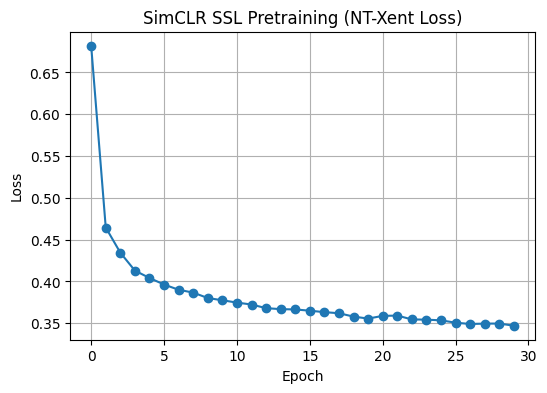

In [7]:
# ============================================================
# CELL 5 – Self-Supervised Learning (SimCLR on Unlabeled Data)
# ============================================================
# Unlabeled dataset: use *all* train images, but ignore labels
unlabeled_paths = train_df["filepath"].values  # Notice: full train_df, NOT train_limited_df
ds_u = tf.data.Dataset.from_tensor_slices(unlabeled_paths)

def random_resized_crop(img, target_height=224, target_width=224, scale=(0.6, 1.0)):
    img = tf.image.convert_image_dtype(img, tf.float32)
    h = tf.shape(img)[0]; w = tf.shape(img)[1]
    area = tf.cast(h * w, tf.float32)
    target_area = tf.random.uniform([], scale[0], scale[1]) * area
    aspect_ratio = tf.random.uniform([], 3/4, 4/3)
    new_w = tf.cast(tf.round(tf.sqrt(target_area * aspect_ratio)), tf.int32)
    new_h = tf.cast(tf.round(tf.sqrt(target_area / aspect_ratio)), tf.int32)
    new_w = tf.minimum(new_w, w); new_h = tf.minimum(new_h, h)
    offset_w = tf.random.uniform([], 0, tf.maximum(w - new_w + 1, 1), dtype=tf.int32)
    offset_h = tf.random.uniform([], 0, tf.maximum(h - new_h + 1, 1), dtype=tf.int32)
    img = tf.image.crop_to_bounding_box(img, offset_h, offset_w, new_h, new_w)
    img = tf.image.resize(img, [target_height, target_width])
    return img

def augment_view_ssl(x):
    x = random_resized_crop(x, IMG_SIZE[0], IMG_SIZE[1], scale=(0.6, 1.0))
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_contrast(x, 0.8, 1.2)
    x = tf.image.random_brightness(x, 0.1)
    return x

def two_views(path):
    x = decode_img(path)
    x = tf.cast(x, tf.float32) / 255.0  # 0–1 for SSL
    v1 = augment_view_ssl(x)
    v2 = augment_view_ssl(x)
    return (v1, v2)

ds_ssl = ds_u.shuffle(4096, seed=SEED).map(
    lambda p: two_views(p),
    num_parallel_calls=AUTOTUNE
)
ds_ssl = ds_ssl.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Encoder backbone for SimCLR
enc_base = ResNet50(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
enc_base.trainable = True

def proj_head(x, dim=128):
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dense(dim, activation=None)(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(x)
    return x

ssl_inp = layers.Input(shape=(*IMG_SIZE, 3))
feat = enc_base(ssl_inp, training=True)
z = proj_head(feat, dim=128)
ssl_encoder = models.Model(ssl_inp, z, name="ssl_encoder")

tau = 0.2

@tf.function
def nt_xent(z1, z2, temperature=tau):
    z1 = tf.math.l2_normalize(z1, axis=1)
    z2 = tf.math.l2_normalize(z2, axis=1)
    B = tf.shape(z1)[0]
    z = tf.concat([z1, z2], axis=0)
    sim = tf.matmul(z, z, transpose_b=True)
    mask = tf.eye(2 * B)
    sim = sim - 1e9 * mask
    sim = sim / temperature
    pos_idx = tf.concat([tf.range(B, 2 * B), tf.range(0, B)], axis=0)
    pos_sim = tf.gather_nd(sim, tf.stack([tf.range(2 * B), pos_idx], axis=1))
    log_prob = pos_sim - tf.reduce_logsumexp(sim, axis=1)
    loss = -tf.reduce_mean(log_prob)
    return loss

ssl_opt = tf.keras.optimizers.Adam(1e-4)

@tf.function
def ssl_train_step(v1, v2):
    with tf.GradientTape() as tape:
        z1 = ssl_encoder(v1, training=True)
        z2 = ssl_encoder(v2, training=True)
        loss = nt_xent(z1, z2, tau)
    grads = tape.gradient(loss, ssl_encoder.trainable_variables)
    ssl_opt.apply_gradients(zip(grads, ssl_encoder.trainable_variables))
    return loss

ssl_loss_history = []
for epoch in range(EPOCHS_SSL_PRE):
    losses = []
    for v1, v2 in ds_ssl:
        loss = ssl_train_step(v1, v2)
        losses.append(loss.numpy())
    epoch_loss = float(np.mean(losses))
    ssl_loss_history.append(epoch_loss)
    print(f"[SimCLR] Epoch {epoch+1}/{EPOCHS_SSL_PRE} - NT-Xent loss: {epoch_loss:.4f}")

plt.figure(figsize=(6,4))
plt.plot(ssl_loss_history, marker="o")
plt.title("SimCLR SSL Pretraining (NT-Xent Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [8]:
# ============================================================
# CELL 6 – Build SSL Classifier (ResNet50 + SimCLR Encoder)
# ============================================================
# Now we turn the SSL encoder backbone into a classifier
x_ssl_cls = layers.GlobalAveragePooling2D()(enc_base.output)
x_ssl_cls = layers.Dropout(0.25)(x_ssl_cls)
out_ssl_cls = layers.Dense(NUM_CLASSES, activation="softmax")(x_ssl_cls)
ssl_model = models.Model(enc_base.input, out_ssl_cls, name="resnet50_ssl_simclr_classifier")

# Optionally freeze earlier layers and fine-tune last N
for layer in enc_base.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

ssl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(ssl_model.summary())

Model: "resnet50_ssl_simclr_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,602,055 (90.03 MB)

 Trainable params: 15,846,151 (60.45 MB)

 Non-trainable params: 7,755,904 (29.59 MB)

None


In [9]:
# ============================================================
# CELL 7 – Train All Three Models (Supervised & SSL)
# ============================================================
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    EarlyStopping(monitor="val_loss", patience=14, min_delta=0.001, 
    mode='min', restore_best_weights=True, verbose=1),
]

print(">>> Training ResNet50 (Supervised)")
hist_resnet = resnet50_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SUP,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

print(">>> Training EfficientNetB0 (Supervised)")
hist_effnet = effnetb0_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SUP,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

print(">>> Training ResNet50 + SimCLR (SSL + Supervised)")
hist_ssl = ssl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SUP,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

>>> Training ResNet50 (Supervised)
Epoch 1/10


I0000 00:00:1764590226.497044      62 service.cc:148] XLA service 0x7d819c1894b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764590226.499027      62 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1764590226.499048      62 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 1/45 ━━━━━━━━━━━━━━━━━━━━ 18:25 25s/step - accuracy: 0.0625 - loss: 1.9810

I0000 00:00:1764590239.163510      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 ━━━━━━━━━━━━━━━━━━━━ 47s 508ms/step - accuracy: 0.3289 - loss: 1.6557 - val_accuracy: 0.7145 - val_loss: 1.1226 - learning_rate: 1.0000e-04
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 395ms/step - accuracy: 0.6381 - loss: 0.7332 - val_accuracy: 0.7195 - val_loss: 1.3236 - learning_rate: 1.0000e-04
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 385ms/step - accuracy: 0.7177 - loss: 0.5067 - val_accuracy: 0.6883 - val_loss: 1.0903 - learning_rate: 1.0000e-04
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 390ms/step - accuracy: 0.8227 - loss: 0.2896 - val_accuracy: 0.6671 - val_loss: 1.1213 - learning_rate: 1.0000e-04
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.8458 - loss: 0.2049
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 429ms/step - accuracy: 0.8463 - loss: 0.2044 - val_accuracy: 0.6509 - val_loss: 1.3980 - learning_rate: 1.0000e-04
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 459ms/step - accuracy: 0.8963 - l

E0000 00:00:1764590451.343273      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1764590451.484454      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


45/45 ━━━━━━━━━━━━━━━━━━━━ 59s 510ms/step - accuracy: 0.1754 - loss: 2.1884 - val_accuracy: 0.4426 - val_loss: 1.6296 - learning_rate: 1.0000e-04
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 314ms/step - accuracy: 0.3062 - loss: 1.6280 - val_accuracy: 0.5748 - val_loss: 1.4144 - learning_rate: 1.0000e-04
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 318ms/step - accuracy: 0.3976 - loss: 1.3837 - val_accuracy: 0.5985 - val_loss: 1.2591 - learning_rate: 1.0000e-04
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step - accuracy: 0.4642 - loss: 1.1479 - val_accuracy: 0.6060 - val_loss: 1.1508 - learning_rate: 1.0000e-04
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 330ms/step - accuracy: 0.5029 - loss: 1.0724 - val_accuracy: 0.6284 - val_loss: 1.0863 - learning_rate: 1.0000e-04
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 318ms/step - accuracy: 0.5544 - loss: 0.9145 - val_accuracy: 0.6135 - val_loss: 1.0946 - learning_rate: 1.0000e-04
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 14s 312ms/step - accuracy: 0.56

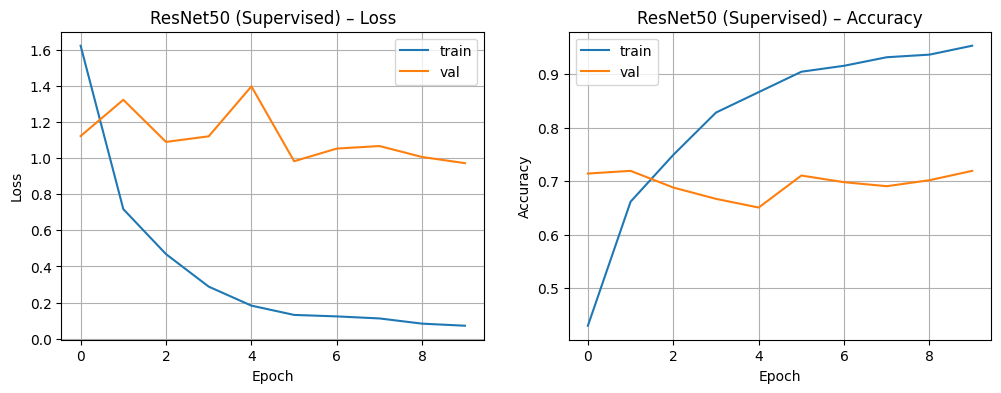

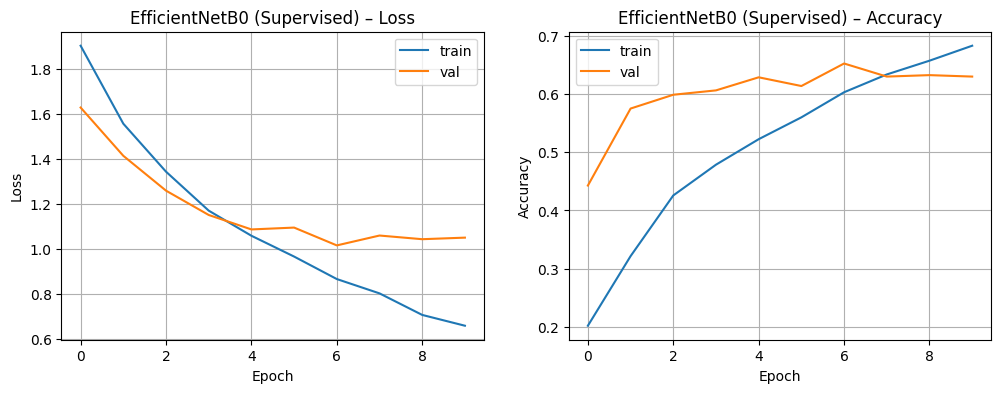

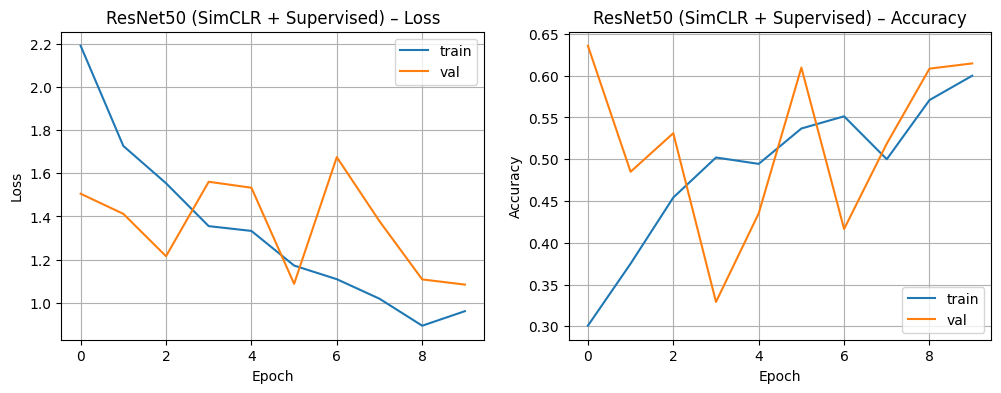

In [10]:
# ============================================================
# CELL 8 – Helper: Plot Training Curves
# ============================================================
def plot_history(hist, title_prefix):
    plt.figure(figsize=(12,4))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix} – Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix} – Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.show()

plot_history(hist_resnet, "ResNet50 (Supervised)")
plot_history(hist_effnet, "EfficientNetB0 (Supervised)")
plot_history(hist_ssl,   "ResNet50 (SimCLR + Supervised)")


In [11]:
# ============================================================
# CELL 9 – Evaluation: Single Models + Ensemble
# ============================================================
# Collect true labels from test set
y_true = np.concatenate([yb.numpy() for xb, yb in test_ds], axis=0)

def predict_proba(model, dataset):
    probs = []
    for xb, _ in dataset:
        p = model.predict(xb, verbose=0)
        probs.append(p)
    return np.concatenate(probs, axis=0)

print(">>> Getting predictions on test set ...")
y_prob_res   = predict_proba(resnet50_model, test_ds)
y_prob_eff   = predict_proba(effnetb0_model, test_ds)
y_prob_ssl   = predict_proba(ssl_model, test_ds)

y_pred_res   = y_prob_res.argmax(axis=1)
y_pred_eff   = y_prob_eff.argmax(axis=1)
y_pred_ssl   = y_prob_ssl.argmax(axis=1)

# --- Simple soft-voting ensemble: average probabilities ---
y_prob_ensemble = (y_prob_res + y_prob_eff + y_prob_ssl) / 3.0
y_pred_ensemble = y_prob_ensemble.argmax(axis=1)

>>> Getting predictions on test set ...


In [12]:
# ============================================================
# CELL 10 – Reports: Single Models + Ensemble
# ============================================================
print("=== ResNet50 (Supervised) – Test Classification Report ===")
print(classification_report(y_true, y_pred_res, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)]))

print("=== EfficientNetB0 (Supervised) – Test Classification Report ===")
print(classification_report(y_true, y_pred_eff, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)]))

print("=== ResNet50 + SimCLR (SSL) – Test Classification Report ===")
print(classification_report(y_true, y_pred_ssl, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)]))

print("=== Ensemble (Average of 3 models) – Test Classification Report ===")
print(classification_report(y_true, y_pred_ensemble, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)]))

# Overall ROC-AUC for ensemble
try:
    roc_ovr_ensemble = roc_auc_score(y_true, y_prob_ensemble, multi_class="ovr")
    print("Ensemble ROC-AUC (OvR):", roc_ovr_ensemble)
except Exception as e:
    print("ROC-AUC error:", e)

=== ResNet50 (Supervised) – Test Classification Report ===
              precision    recall  f1-score   support

       akiec       0.49      0.34      0.40        65
         bcc       0.74      0.54      0.63       103
         bkl       0.50      0.66      0.57       220
          df       0.17      0.26      0.21        23
         mel       0.44      0.56      0.49       223
          nv       0.91      0.85      0.88      1341
        vasc       0.83      0.54      0.65        28

    accuracy                           0.75      2003
   macro avg       0.58      0.54      0.55      2003
weighted avg       0.78      0.75      0.76      2003

=== EfficientNetB0 (Supervised) – Test Classification Report ===
              precision    recall  f1-score   support

       akiec       0.26      0.48      0.33        65
         bcc       0.39      0.73      0.51       103
         bkl       0.47      0.43      0.45       220
          df       0.21      0.39      0.28        23
        

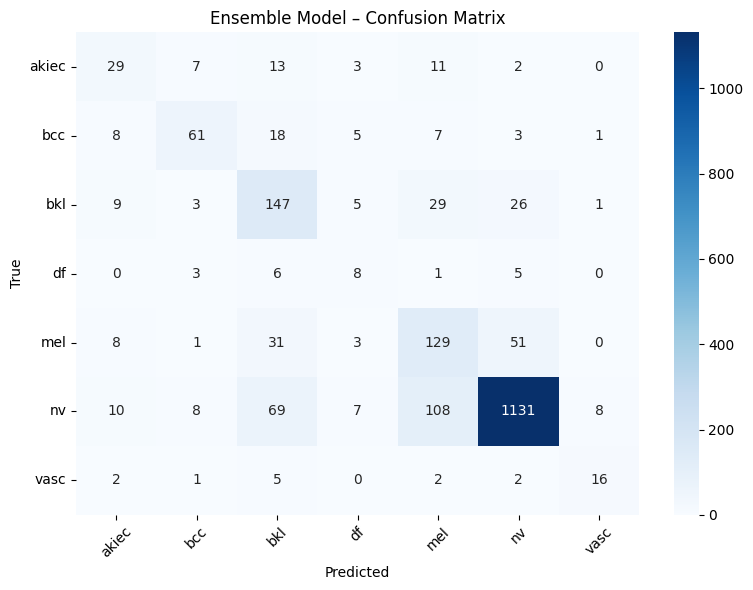

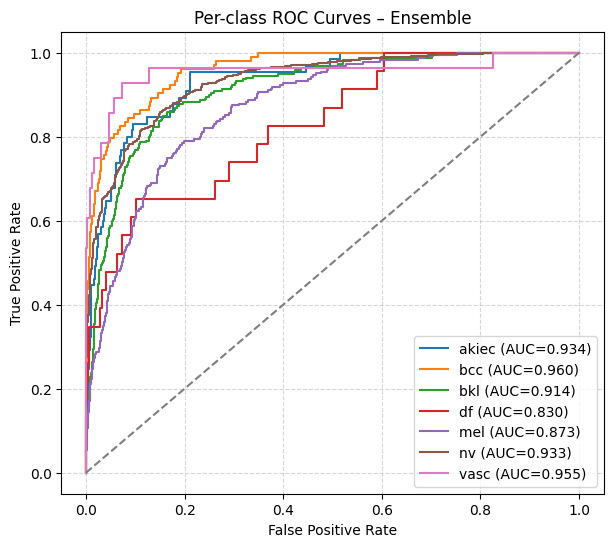

In [13]:
# ============================================================
# CELL 11 – Confusion Matrix & ROC Curves (Ensemble)
# ============================================================
# Confusion matrix
cm_ens = confusion_matrix(y_true, y_pred_ensemble)
plt.figure(figsize=(8,6))
sns.heatmap(cm_ens, annot=True, fmt="d",
            cmap="Blues",
            xticklabels=[idx_to_class[i] for i in range(NUM_CLASSES)],
            yticklabels=[idx_to_class[i] for i in range(NUM_CLASSES)])
plt.title("Ensemble Model – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class ROC for ensemble
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(7,6))
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob_ensemble[:, i])
    auc_val = roc_auc_score(y_true_bin[:, i], y_prob_ensemble[:, i])
    plt.plot(fpr, tpr, label=f"{idx_to_class[i]} (AUC={auc_val:.3f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-class ROC Curves – Ensemble")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()